# Raw Reaction Model Bakeoff Control Panel

Use this notebook to run the full experiment from one place: freeze tasks, run candidate generation, run the strong-model gold audit, run self-validation, score results, and inspect visuals.

Live model calls are behind explicit switches in the setup cell. Start with a smoke run before spending on the full configuration.

## 1. Setup

In [1]:
from pathlib import Path
from pprint import pprint
import json
import os
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = cwd
while REPO_ROOT.name != "chemy" and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
assert REPO_ROOT.name == "chemy", (
    f"Could not find repo root named 'chemy' — walked up to {REPO_ROOT}. "
    "Launch Jupyter from inside the chemy repository."
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.model_quality.helpers import load_config, read_jsonl
from experiments.model_quality.sample import build_tasks
from experiments.model_quality.run_generation import run_generation
from experiments.model_quality.run_gold_audit import run_gold_audit
from experiments.model_quality.run_self_validation import run_self_validation
from experiments.model_quality.score import build_summary

CONFIG_PATH = REPO_ROOT / "experiments" / "model_quality" / "config.yaml"

# Safety switches — keep False until you intentionally want to call live models.
RUN_FREEZE_TASKS = True
RUN_GENERATION = True
RUN_GOLD_AUDIT = True
RUN_SELF_VALIDATION = True
RUN_SCORE = True

# Smoke mode overrides the loaded config in-memory only. It does not edit config.yaml.
SMOKE_MODE = False
SMOKE_MODELS = ["openai/gpt-oss-120b"]
SMOKE_PRESETS = ["wiki_crc_rp"]
SMOKE_COMPLEXITY_BANDS = ["simple"]
SMOKE_GENERATION_RUN_LIMIT = 2
SMOKE_MAX_WORKERS = 2

DATA_DIR = REPO_ROOT / "experiments" / "model_quality" / ("data_smoke" if SMOKE_MODE else "data")
SUMMARY_PATH = DATA_DIR / "summary.json"

config = load_config(CONFIG_PATH)
if SMOKE_MODE:
    config = {
        **config,
        "tasks_per_band": 1,
        "gold_rounds": 1,
        "candidate_models": SMOKE_MODELS,
        "bakeoff_presets": SMOKE_PRESETS,
        "complexity_bands": SMOKE_COMPLEXITY_BANDS,
        "generation_self_review": False,
        "validation_rounds": 1,
        "validation_batch_size": 2,
        "max_workers": SMOKE_MAX_WORKERS,
    }
GENERATION_RUN_LIMIT = SMOKE_GENERATION_RUN_LIMIT if SMOKE_MODE else None

print(f"Repo root: {REPO_ROOT}")
print(f"Config:    {CONFIG_PATH}")
print(f"Data dir:  {DATA_DIR}")
print(f"API key present: {bool(os.getenv('OPENROUTER_API_KEY'))}")
print(f"Live switches: freeze={RUN_FREEZE_TASKS}, generation={RUN_GENERATION}, gold={RUN_GOLD_AUDIT}, self_validation={RUN_SELF_VALIDATION}, score={RUN_SCORE}")
print(f"Generation run limit: {GENERATION_RUN_LIMIT}")
print(f"Max workers: {config['max_workers']}")
pprint(config)

Repo root: /home/canary/Documents/Code/chemy
Config:    /home/canary/Documents/Code/chemy/experiments/model_quality/config.yaml
Data dir:  /home/canary/Documents/Code/chemy/experiments/model_quality/data
API key present: True
Live switches: freeze=True, generation=True, gold=True, self_validation=True, score=True
Generation run limit: None
Max workers: 20
{'acceptance_threshold': 0.4,
 'bakeoff_presets': ['wiki_crc_rp',
                     'simple_inorganic_wiki_rp',
                     'simple_organic_wiki_rp',
                     'oxidizers_wiki_rp',
                     'corrosive_wiki_rp'],
 'batch_size': 5,
 'candidate_models': ['openai/gpt-oss-120b',
                      'qwen/qwen3-235b-a22b',
                      'x-ai/grok-4-fast',
                      'deepseek/deepseek-v3.2'],
 'chemy_data_dir': 'data',
 'complexity_bands': ['simple', 'medium', 'hard'],
 'generation_self_review': False,
 'gold_rounds': 3,
 'max_workers': 20,
 'seed': 1729,
 'strong_model': 'google/gemi

## 2. Freeze Tasks

In [2]:
if RUN_FREEZE_TASKS:
    tasks_path, task_manifest = build_tasks(config, data_dir=DATA_DIR, root=REPO_ROOT)
    print(f"Wrote {task_manifest['task_n']} tasks to {tasks_path}")
else:
    task_manifest_path = DATA_DIR / "manifests" / "task_manifest.json"
    task_manifest = json.loads(task_manifest_path.read_text()) if task_manifest_path.exists() else None
    print("Task freezing skipped.")

tasks = read_jsonl(DATA_DIR / "tasks.jsonl")
print(f"Frozen task rows: {len(tasks)}")
tasks[:3]

Wrote 75 tasks to /home/canary/Documents/Code/chemy/experiments/model_quality/data/tasks.jsonl
Frozen task rows: 75


[{'task_id': 'task:9e2807a7382066c261b1f7f55ddef22ddd5a09a4',
  'cid': 14827,
  'compound_name': 'Lead monoxide',
  'preset': 'wiki_crc_rp',
  'position': 'any',
  'scope': 'documented_less_common',
  'prompt': 'Provide a list of documented chemical reactions involving Lead monoxide, where it appears as a reagent or product. Include not only the most common reactions, but also less common or unusual ones, as long as you are absolutely sure they are real and correct. Return one JSON object per line (JSONL). Each JSON object has these fields:\n- "reagents": list of {"name": "<clean chemical name>", "phase": "<g|l|s|aq>"}\n- "products": list of {"name": "<clean chemical name>", "phase": "<g|l|s|aq>"}\n- Optional "solvent": primary solvent name or null\n- Optional "catalyst": catalyst name or null\n- Optional per-compound "note": short qualifier; omit it when not needed\n\nRules:\n- Use full chemical names, not formulas.\n- The name field must contain ONLY the chemical name.\n- Put qualifi

## 3. Run Candidate Generation

In [ ]:
if RUN_GENERATION:
    generation_manifest = run_generation(
        config,
        data_dir=DATA_DIR,
        root=REPO_ROOT,
        models=config["candidate_models"],
        run_limit=GENERATION_RUN_LIMIT,
        max_workers=config["max_workers"],
    )
    pprint(generation_manifest)
else:
    print("Generation skipped.")

generations = read_jsonl(DATA_DIR / "generations.jsonl")
candidates = read_jsonl(DATA_DIR / "candidates.jsonl")
print(f"Generation rows: {len(generations)}")
print(f"Candidate rows:  {len(candidates)}")
candidates[:3]

[11:59:19] INFO     Generating model-quality reactions: submitted 375 entries                          ]8;id=607783;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=465843;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#45\45]8;;\

Output()

## 4. Run Gold Audit

In [2]:
if RUN_GOLD_AUDIT:
    pending_candidates = read_jsonl(DATA_DIR / "candidates.jsonl")
    if not pending_candidates:
        print("No candidates found — run the generation cell first.")
    else:
        print(f"Submitting gold audit for up to {len(pending_candidates)} candidates.")
        gold_manifest = run_gold_audit(
            config,
            data_dir=DATA_DIR,
            model=config["strong_model"],
            max_workers=config["max_workers"],
        )
        pprint(gold_manifest)
        if gold_manifest.get("batch_failures", 0):
            print(
                f"\nWARNING: {gold_manifest['batch_failures']} batch(es) failed. "
                "Re-run this cell to retry."
            )
else:
    print("Gold audit skipped.")

gold_audits = read_jsonl(DATA_DIR / "gold_audits.jsonl")
print(f"Gold audit rows: {len(gold_audits)}")
gold_audits[:3]

Submitting gold audit for up to 1851 candidates.
Running gold audit batches: submitted 717 entries
{'audited': 1191,
 'batch_failures': 0,
 'candidate_count': 1851,
 'completed_before': 660,
 'max_workers': 20,
 'model': 'google/gemini-2.5-pro',
 'pending_count': 1191,
 'rounds': 3}
Gold audit rows: 1851


[{'candidate_id': 'candidate:265359eaab24b1e41f181732329a73c6d41a2155',
  'task_id': 'task:9e2807a7382066c261b1f7f55ddef22ddd5a09a4',
  'model': 'openai/gpt-oss-120b',
  'rid': 'n/KFmqAW+vNtNTaoCPUBtQ==',
  'output_id': 'reaction:524797c9dbd58154c355649f0cfe4ac9ebe8b3c5',
  'gold_model': 'google/gemini-2.5-pro',
  'gold_votes': [{'index': 1, 'valid': True},
   {'index': 1, 'valid': True},
   {'index': 1, 'valid': True}],
  'gold_rounds': 3,
  'gold_positives': 3,
  'gold_confidence': 1.0},
 {'candidate_id': 'candidate:8650706e048e5c739325409055e4a6ef2e4ee3cf',
  'task_id': 'task:9e2807a7382066c261b1f7f55ddef22ddd5a09a4',
  'model': 'openai/gpt-oss-120b',
  'rid': 'sz4AYgh0TQxel3d/YNO+JQ==',
  'output_id': 'reaction:5ca4f7b3935bdd07cf01c17adb9f2d2d26be7e81',
  'gold_model': 'google/gemini-2.5-pro',
  'gold_votes': [{'index': 2, 'valid': True},
   {'index': 2, 'valid': True},
   {'index': 2, 'valid': True}],
  'gold_rounds': 3,
  'gold_positives': 3,
  'gold_confidence': 1.0},
 {'candida

## 5. Run Self-Validation

In [ ]:
if RUN_SELF_VALIDATION:
    pending_candidates = read_jsonl(DATA_DIR / "candidates.jsonl")
    if not pending_candidates:
        print("No candidates found — run the generation cell first.")
    else:
        print(f"Submitting self-validation for up to {len(pending_candidates)} candidates.")
        self_validation_manifest = run_self_validation(
            config,
            data_dir=DATA_DIR,
            root=REPO_ROOT,
            models=config.get("validation_models") or config["candidate_models"],
            run_limit=GENERATION_RUN_LIMIT,
            max_workers=config["max_workers"],
        )
        pprint(self_validation_manifest)
else:
    print("Self-validation skipped.")

self_validations = read_jsonl(DATA_DIR / "self_validation_runs.jsonl")
print(f"Self-validation rows: {len(self_validations)}")
self_validations[:3]

Submitting self-validation for up to 1851 candidates.


[14:30:56] INFO     Running self-validation: submitted 370 entries                                     ]8;id=259814;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=300615;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#45\45]8;;\

Output()

[14:54:56] ERROR    Exception occured: Expecting value: line 257 column 1 (char 1408)                  ]8;id=598526;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=279831;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#56\56]8;;\

[14:55:09] ERROR    Exception occured: Expecting value: line 207 column 1 (char 1133)                  ]8;id=475276;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=801744;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#56\56]8;;\

...

[15:59:35] ERROR    Exception occured: Expecting value: line 1171 column 1 (char 6435)                 ]8;id=735201;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=729508;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#56\56]8;;\

[16:00:05] ERROR    Exception occured: Expecting value: line 833 column 1 (char 4576)                  ]8;id=910005;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=677009;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#56\56]8;;\

[16:12:45] ERROR    Exception occured: Expecting value: line 273 column 1 (char 1496)                  ]8;id=917784;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=878307;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#56\56]8;;\

[16:34:10] ERROR    Exception occured: Expecting value: line 1019 column 1 (char 5599)                 ]8;id=128300;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=482943;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#56\56]8;;\

[16:57:02] ERROR    Exception occured: Expecting value: line 2319 column 1 (char 12749)                ]8;id=928103;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=616341;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#56\56]8;;\

## 6. Score

In [2]:
summary = build_summary(
    data_dir=DATA_DIR,
    validation_thresholds=config.get("validation_thresholds"),
)
if RUN_SCORE:
    SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    SUMMARY_PATH.write_text(json.dumps(summary, indent=2) + "\n")
    print(f"Wrote {SUMMARY_PATH}")

summary["inputs"], summary["models"]

Wrote /home/canary/Documents/Code/chemy/experiments/model_quality/data/summary.json


({'generations': 334,
  'candidates': 1851,
  'gold_audits': 1851,
  'self_validations': 1783},
 {'openai/gpt-oss-120b': {'generation_runs': 75,
   'candidate_n': 555,
   'schema_success_rate': 0.9519725557461407,
   'parsed_rate': 0.6504504504504505,
   'target_compound_rate': 0.6468468468468469,
   'target_position_rate': 0.6468468468468469,
   'balance_success_rate': 0.44324324324324327,
   'unique_rid_n': 360,
   'unique_output_id_n': 555,
   'duplicate_rid_rate': 0.0027700831024930483,
   'gold_audited_n': 555,
   'gold_coverage': 1.0,
   'mean_gold_confidence': 0.7537537537537538,
   'macro_mean_gold_confidence': 0.7544427323187386,
   'expected_unique_valid_rid_n': 279.0,
   'input_tokens': 493236,
   'completion_tokens': 3903453,
   'expected_unique_valid_rids_per_1k_tokens': 0.0634568421828335},
  'qwen/qwen3-235b-a22b': {'generation_runs': 75,
   'candidate_n': 402,
   'schema_success_rate': 0.8796498905908097,
   'parsed_rate': 0.736318407960199,
   'target_compound_rate': 0

## 7. Visuals

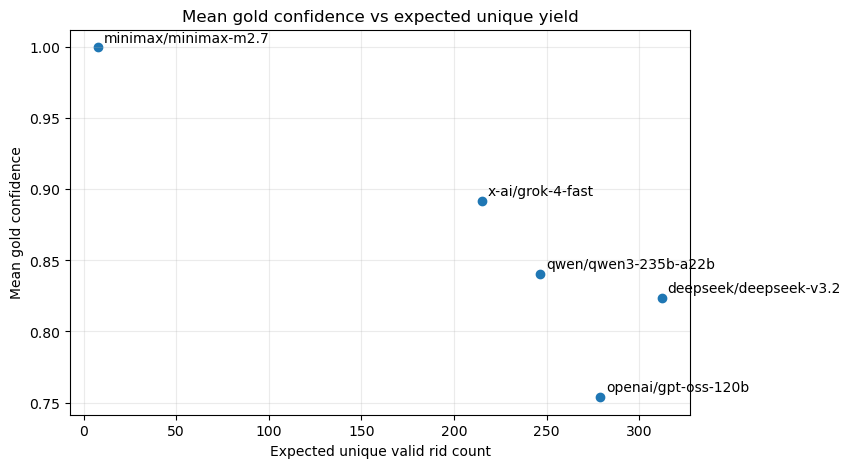

In [3]:
import matplotlib.pyplot as plt

models = list(summary["models"])
if not models:
    print("No scored models yet. Run generation and gold audit first.")
else:
    confidence = [summary["models"][m]["mean_gold_confidence"] for m in models]
    yield_ = [summary["models"][m]["expected_unique_valid_rid_n"] for m in models]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(yield_, confidence)
    for m, x, y in zip(models, yield_, confidence):
        ax.annotate(m, (x, y), xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Expected unique valid rid count")
    ax.set_ylabel("Mean gold confidence")
    ax.set_title("Mean gold confidence vs expected unique yield")
    ax.grid(True, alpha=0.25)

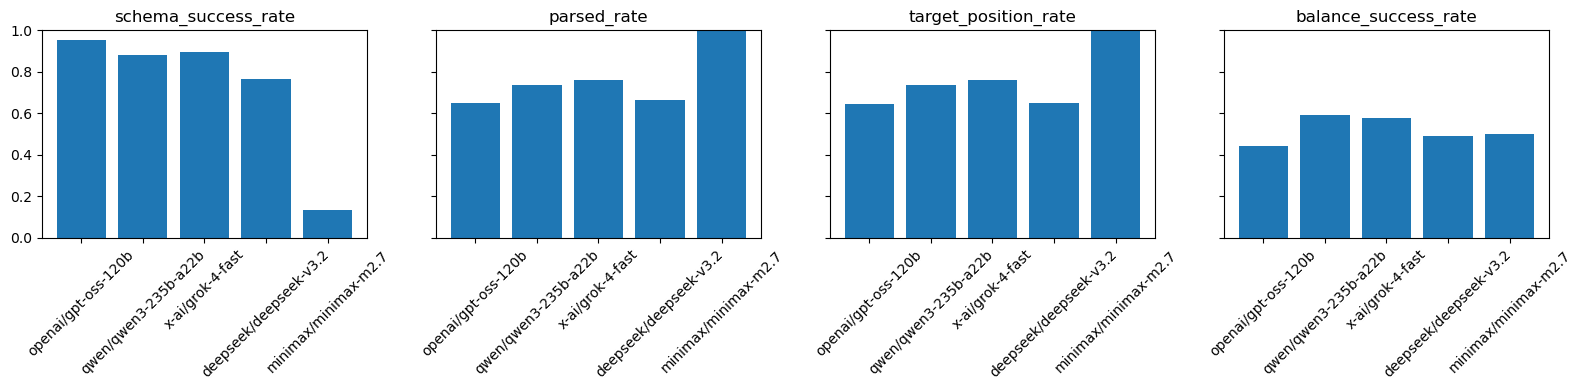

In [4]:
metrics = ["schema_success_rate", "parsed_rate", "target_position_rate", "balance_success_rate"]
if models:
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=True)
    for ax, metric in zip(axes, metrics):
        ax.bar(models, [summary["models"][m][metric] for m in models])
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylim(0, 1)
    fig.tight_layout()

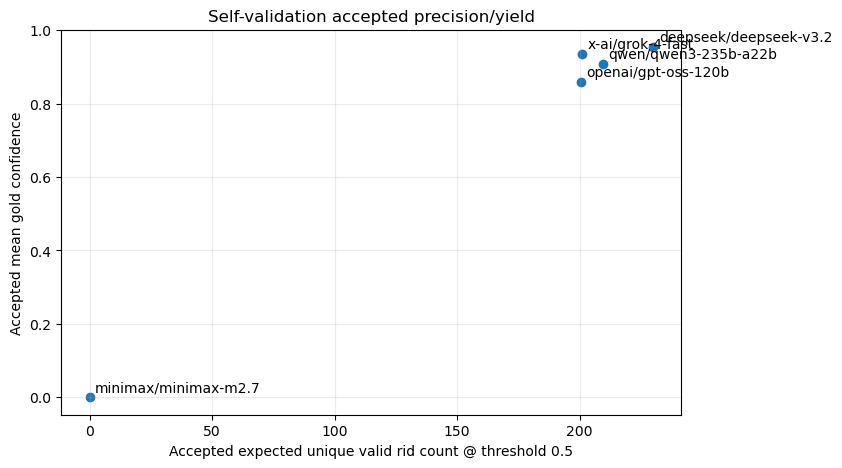

In [5]:
self_validation = summary.get("self_validation", {})
thresholds = self_validation.get("thresholds", {})
threshold_key = "0.5" if "0.5" in thresholds else next(iter(thresholds), None)
if threshold_key is None or not thresholds.get(threshold_key):
    print("No self-validation threshold metrics yet.")
else:
    rows = thresholds[threshold_key]
    models = list(rows)
    precision = [rows[m]["precision_estimate"] for m in models]
    yield_ = [rows[m]["accepted_expected_unique_valid_rid_n"] for m in models]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(yield_, precision)
    for m, x, y in zip(models, yield_, precision):
        ax.annotate(m, (x, y), xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel(f"Accepted expected unique valid rid count @ threshold {threshold_key}")
    ax.set_ylabel("Accepted mean gold confidence")
    ax.set_title("Self-validation accepted precision/yield")
    ax.grid(True, alpha=0.25)

In [6]:
summary["bands"]

{'wiki_crc_rp:hard': {'openai/gpt-oss-120b': {'candidate_n': 30,
   'parsed_rate': 0.3,
   'target_position_rate': 0.3,
   'balance_success_rate': 0.2,
   'gold_audited_n': 30,
   'mean_gold_confidence': 0.7,
   'expected_unique_valid_rid_n': 7.0,
   'gold_coverage': 1.0},
  'qwen/qwen3-235b-a22b': {'candidate_n': 21,
   'parsed_rate': 0.38095238095238093,
   'target_position_rate': 0.38095238095238093,
   'balance_success_rate': 0.23809523809523808,
   'gold_audited_n': 21,
   'mean_gold_confidence': 0.8095238095238095,
   'expected_unique_valid_rid_n': 5.0,
   'gold_coverage': 1.0},
  'x-ai/grok-4-fast': {'candidate_n': 16,
   'parsed_rate': 0.5625,
   'target_position_rate': 0.5625,
   'balance_success_rate': 0.375,
   'gold_audited_n': 16,
   'mean_gold_confidence': 0.6041666666666666,
   'expected_unique_valid_rid_n': 4.666666666666667,
   'gold_coverage': 1.0},
  'deepseek/deepseek-v3.2': {'candidate_n': 35,
   'parsed_rate': 0.42857142857142855,
   'target_position_rate': 0.4285